In [7]:
import json
import pandas as pd
import glob
from pathlib import Path
import plotly
import numpy as np

In [4]:
root_dir = "../model/new_logs"

In [11]:
records = {}
for file in glob.glob(f'{root_dir}/**/metadata.json'):
    path = Path(file)
    name = path.parent.stem

    print(name)
    with open(file, 'r') as f:
        data = json.load(f)

    if 'test_metrics' not in data['data']:
        continue
    records[name] = {}
    grouped_data = {}
    finished_folds = 0
    
    for fold in data['data']['test_metrics']:
        if fold == {}:
            continue
        for key, val in fold.items():
            if key not in grouped_data:
                grouped_data[key] = []
                
            grouped_data[key].append(val)
        finished_folds += 1
    for key in grouped_data.keys():
        records[name][f'{key}_avg'] = np.average(grouped_data[key])
        records[name][f'{key}_std'] = np.std(grouped_data[key])
    records[name]['finished_folds'] = finished_folds
    
df = pd.DataFrame.from_dict(records).T
df.sort_values('test_auprc', ascending=False)

finetuning_STY_3_perturb2_dbptm
finetuning_Y_3_perturb2_dbptm


KeyError: 'test_auprc'

In [32]:
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, auc

def plot_plotly_multifold_prc(all_labels, all_probs):
    """
    Plots an interactive multifold PRC curve using Plotly.
    """
    fig = go.Figure()
    
    mean_recall = np.linspace(0, 1, 100)
    all_precisions = []
    aucs = []

    # 1. Add individual folds
    for i, (labels, probs) in enumerate(zip(all_labels, all_probs)):
        precision, recall, _ = precision_recall_curve(labels, probs)
        prc_auc = auc(recall, precision)
        aucs.append(prc_auc)

        # Interpolate for the mean calculation later
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
        all_precisions.append(interp_precision)

        fig.add_trace(go.Scatter(
            x=recall, y=precision,
            mode='lines',
            name=f'Fold {i+1} (AUC = {prc_auc:.2f})',
            line=dict(width=1, color='rgba(100, 100, 100, 0.3)'),
            hoverinfo='name+x+y'
        ))

    # 2. Calculate Mean and Std Dev
    mean_precision = np.mean(all_precisions, axis=0)
    mean_auc = auc(mean_recall, mean_precision)
    std_precision = np.std(all_precisions, axis=0)
    
    # Upper and lower bounds for the shaded area
    precision_upper = np.minimum(mean_precision + std_precision, 1)
    precision_lower = np.maximum(mean_precision - std_precision, 0)

    # 3. Add Standard Deviation Shading
    # We use 'toself' fill logic by combining upper and lower paths
    fig.add_trace(go.Scatter(
        x=np.concatenate([mean_recall, mean_recall[::-1]]),
        y=np.concatenate([precision_upper, precision_lower[::-1]]),
        fill='toself',
        fillcolor='rgba(0, 100, 255, 0.1)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name=f'± 1 Std. Dev.'
    ))

    # 4. Add Mean PRC Curve
    fig.add_trace(go.Scatter(
        x=mean_recall, y=mean_precision,
        mode='lines',
        name=f'Mean PRC (AUC = {mean_auc:.2f})',
        line=dict(color='blue', width=3),
        hoverinfo='all'
    ))

    # Layout improvements
    fig.update_layout(
        title='Multi-fold Precision-Recall Curve',
        xaxis_title='Recall',
        yaxis_title='Precision',
        yaxis=dict(scaleanchor="x", scaleratio=1, range=[0, 1.05]),
        xaxis=dict(range=[0, 1.05]),
        legend=dict(yanchor="bottom", y=0.01, xanchor="left", x=0.01, bgcolor="rgba(255,255,255,0.5)"),
        template="plotly_white",
        hovermode="x unified"
    )

    fig.show()

# --- Example Usage ---
if __name__ == "__main__":
    # Mock data generation
    mock_labels = [np.random.randint(0, 2, 100) for _ in range(5)]
    mock_probs = [np.random.dirichlet(np.ones(2), 100)[:, 1] for _ in range(5)]
    
    plot_plotly_multifold_prc(mock_labels, mock_probs)

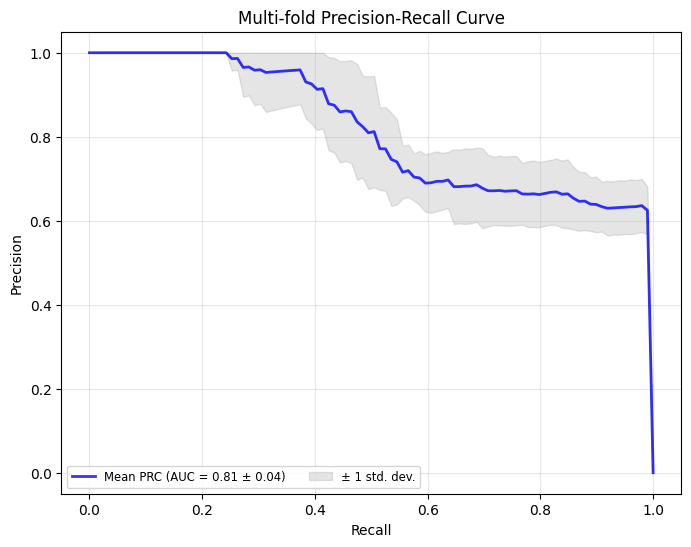

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_multifold_prc(all_labels, all_probs, plot_folds=False):
    """
    Plots per-fold PRC curves and their mean.
    
    Args:
        all_labels (list of arrays): True binary labels for each fold.
        all_probs (list of arrays): Predicted probabilities for each fold.
    """
    plt.figure(figsize=(8, 6))
    
    # Define a common set of recall levels for interpolation
    mean_recall = np.linspace(0, 1, 100)
    precisions = []
    aucs = []

    for i, (labels, probs) in enumerate(zip(all_labels, all_probs)):
        precision, recall, _ = precision_recall_curve(labels, probs)
        prc_auc = average_precision_score(labels, probs)
        aucs.append(prc_auc)

        if plot_folds:
            # Plot individual fold (low opacity)
            plt.plot(recall, precision, lw=1, alpha=0.3, 
                    label=f'Fold {i+1} (AUC = {prc_auc:.2f})')

        # Interpolate precision to match the common recall scale
        # We use [::-1] because recall is naturally decreasing in precision_recall_curve
        interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])
        precisions.append(interp_precision)

    # Calculate Mean and Std
    mean_precision = np.mean(precisions, axis=0)
    # Ensure the curve starts at 1 (standard for PR curves)
    mean_precision[-1] = 0.0 
    mean_auc = auc(mean_recall, mean_precision)
    std_auc = np.std(aucs)

    # Plot the Mean Curve (high opacity)
    plt.plot(mean_recall, mean_precision, color='b',
             label=f'Mean PRC (AUC = {mean_auc:.2f} ± {std_auc:.2f})',
             lw=2, alpha=0.8)

    # Optional: Fill the standard deviation area
    std_precision = np.std(precisions, axis=0)
    precisions_upper = np.minimum(mean_precision + std_precision, 1)
    precisions_lower = np.maximum(mean_precision - std_precision, 0)
    plt.fill_between(mean_recall, precisions_lower, precisions_upper, color='grey', alpha=0.2,
                     label='± 1 std. dev.')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Multi-fold Precision-Recall Curve')
    plt.legend(loc="lower left", fontsize='small', ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

# --- Example Usage ---
if __name__ == "__main__":
    # Generating dummy data for 5 folds
    from sklearn.datasets import make_classification
    
    mock_labels = []
    mock_probs = []
    
    for _ in range(5):
        # Create a slightly noisy dataset per fold
        y_true = np.random.randint(0, 2, size=100)
        y_scores = np.random.uniform(0, 1, size=100)
        # Shift scores to simulate actual predictive power
        y_scores = np.where(y_true == 1, y_scores + 0.2, y_scores - 0.2)
        y_scores = np.clip(y_scores, 0, 1)
        
        mock_labels.append(y_true)
        mock_probs.append(y_scores)

    plot_multifold_prc(mock_labels, mock_probs)

In [23]:
exp_name = 'finetuning_STY_3_perturb2_dbptm'
fold_preds = []
fold_labels = []
for file in glob.glob(f'{root_dir}/{exp_name}/*/test_preds*.json'):
    data = pd.read_json(file)
    fold_preds.append(np.concatenate(data.logits.to_numpy()))
    fold_labels.append(np.concatenate(data.labels.to_numpy())) 

In [25]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

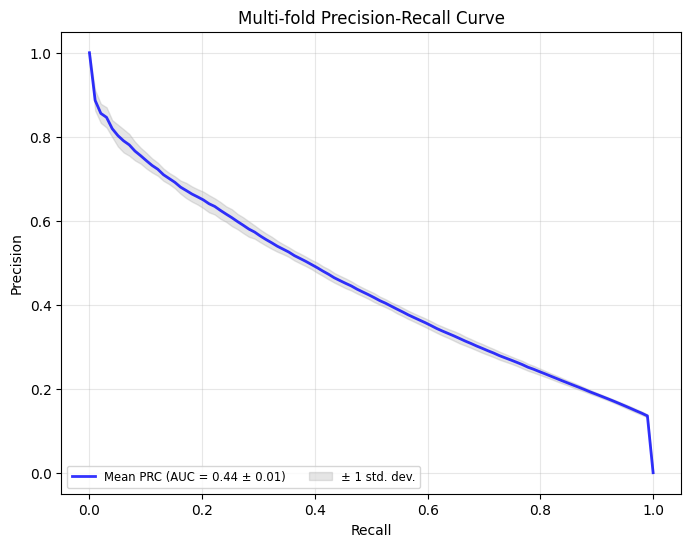

In [39]:
plot_multifold_prc(fold_labels, list(map(sigmoid, fold_preds)))

In [ ]:
def graph_auprc(root_dir, exp_name):

    for file in glob.glob(f'{root_dir}/{exp_name}/metadata.json'):
        data = pd.read_json(file)

